In [2]:
import pandas as pd
import numpy as np

import shap
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("../data/cleaned_bank_churn.csv")

In [4]:
df= pd.get_dummies(df, columns = ['country', 'gender'], drop_first = True)

In [5]:
X = df.drop('churn', axis = 1)
y = df['churn']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)


In [7]:
model = pickle.load(open("../models/xgboost_model.pkl", "rb"))


In [8]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

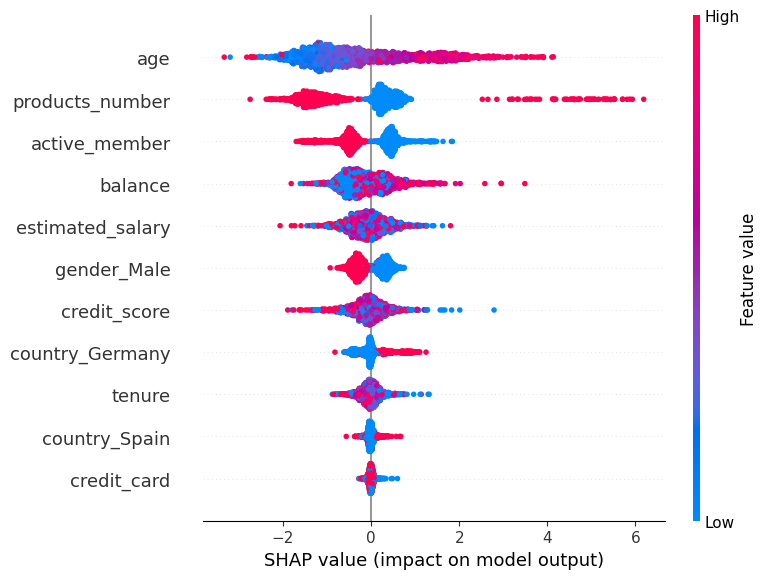

In [9]:
shap.summary_plot(shap_values, X_test)

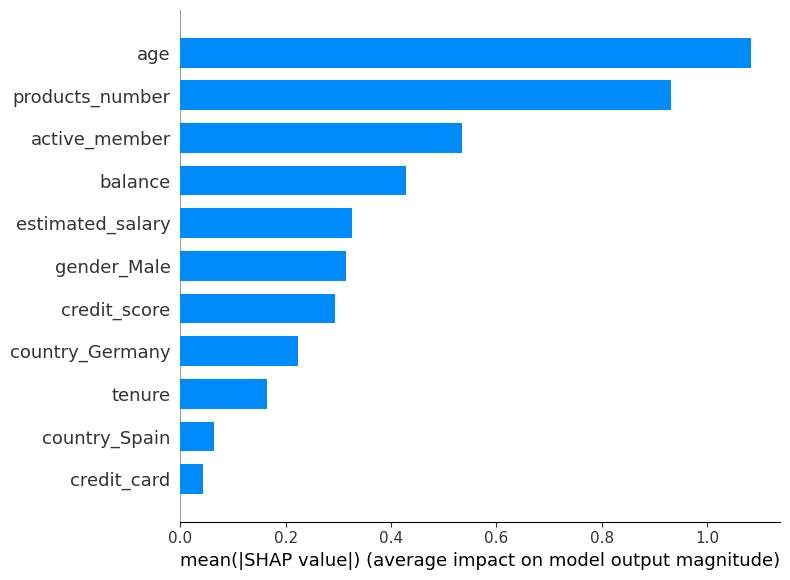

In [10]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [11]:
shap.initjs()

In [12]:
customer_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_test.iloc[customer_index]
)

In [13]:
importance = pd.DataFrame({'Feature': X_test.columns, 'Importance': np.abs(shap_values).mean(axis=0)})
importance.sort_values(by='Importance', ascending=False).head(10)

,Feature,Importance
1,age,1.084235
4,products_number,0.931848
6,active_member,0.535058
3,balance,0.429340
7,estimated_salary,0.325790
10,gender_Male,0.314680
0,credit_score,0.293455
8,country_Germany,0.222915
2,tenure,0.165235
9,country_Spain,0.063542
